# Scoring and Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/03_scoring_and_analysis.ipynb)

This tutorial evaluates TMol's `beta2016` all-atom score function at three levels: whole-pose totals, individual score terms, and block-pair matrices. It also differentiates through the score with PyTorch autograd and performs a small, cloned-coordinate perturbation.

> **Prerequisite.** This notebook assumes the `PoseStack` and device concepts from [Working with TMol](01_working_with_tmol.ipynb). Its block-pair convention is reused by the packing and ligand tutorials.

## Goals

- Separate weighted and unweighted score-term values with the current scorer API.
- Verify that weighted terms sum to the whole-pose score.
- Visualize a residue-block pair energy matrix.
- Compute coordinate gradients and inspect large-gradient atoms.
- Understand what TMol does not provide relative to Rosetta's `Energies` cache.

> **GPU optional.** CUDA is useful for larger batches, but this single-pose example is intentionally CPU-runnable.

## Setup

This setup cell fixes seeds, loads a 30-residue 1UBQ slice from a checked-in fixture, and defines a table helper that uses `itables` when it is installed.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.database import ParameterDatabase
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.io.write_pose_stack_pdb import atom_records_from_pose_stack
from tmol.score.score_function import ScoreFunction
from tmol.score.score_types import ScoreType

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 30)]
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        pose_stack = pose_stack_from_biotite(protein_slice, device, no_optH=True)
except Exception:
    print(pose_diagnostics.getvalue())
    raise
score_function = beta2016_score_function(device)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        display(frame)
        return None
    return show(frame)

print(f"device={device}; input={cif_path.name}; blocks={pose_stack.max_n_blocks}")

device=cpu; input=1UBQ.cif; blocks=30


## Whole-pose weighted and unweighted terms

`render_whole_pose_scoring_module()` binds the score function to this pose layout. With the current scorer API, `sum_terms=False` retains the score-term axis and `apply_weights=False` returns raw term values. The default call sums weighted terms into one score per pose.

In [3]:
whole_scorer = score_function.render_whole_pose_scoring_module(pose_stack)
weighted_terms = whole_scorer(
    pose_stack.coords, sum_terms=False, apply_weights=True
)
unweighted_terms = whole_scorer(
    pose_stack.coords, sum_terms=False, apply_weights=False
)
total = whole_scorer(pose_stack.coords)
score_types = score_function.all_score_types()
weights = score_function.weights_tensor().detach().cpu().numpy()

term_frame = pd.DataFrame(
    {
        "term": [score_type.name for score_type in score_types],
        "weight": weights,
        "unweighted": unweighted_terms[:, 0].detach().cpu().numpy(),
        "weighted": weighted_terms[:, 0].detach().cpu().numpy(),
    }
)
term_frame["abs_weighted"] = term_frame["weighted"].abs()
term_frame = term_frame.sort_values("abs_weighted", ascending=False).drop(
    columns="abs_weighted"
)
show_table(term_frame)
print(f"weighted term sum: {weighted_terms[:, 0].sum().item():.4f}")
print(f"whole-pose total: {total[0].item():.4f}")

weighted term sum: 104.1566
whole-pose total: 104.1566


## Build a focused score function

`beta2016_score_function()` is a complete preset, but a `ScoreFunction` can also start empty. Setting nonzero weights activates the corresponding energy terms. The focused example below is useful for debugging and controlled experiments, not a replacement for a validated full score function.

PR #399 proposes improved term-removal behavior when a weight returns to zero. This tutorial does not demonstrate that unreleased API: construct a new focused score function when changing its active term set until those changes are integrated.

In [4]:
focused_score_function = ScoreFunction(ParameterDatabase.get_default(), device)
focused_score_function.set_weight(ScoreType.fa_ljrep, 0.55)
focused_score_function.set_weight(ScoreType.hbond, 1.0)
focused_scorer = focused_score_function.render_whole_pose_scoring_module(
    pose_stack
)
focused_score = float(focused_scorer(pose_stack.coords).detach().cpu()[0])

focused_rows = [
    {
        "term": score_type.name,
        "weight": float(focused_score_function.get_weight(score_type)),
    }
    for score_type in focused_score_function.all_score_types()
]
show_table(pd.DataFrame(focused_rows))
print(f"focused fa_ljrep + hbond score: {focused_score:.4f}")

focused fa_ljrep + hbond score: 1.2374


**Expected observations.** Raw and weighted columns differ wherever a term's weight is not one. The weighted column must sum to the default whole-pose result within floating-point tolerance. A large magnitude is not automatically an error: bonded, solvation, electrostatic, and reference contributions have different scales and cancellation is common.

## Block-pair energy matrix

`render_block_pair_scoring_module()` returns weighted block-pair values with shape `[n_poses, n_blocks, n_blocks]` when `sum_terms=True`. Keeping `sum_terms=False` adds a leading score-term axis.

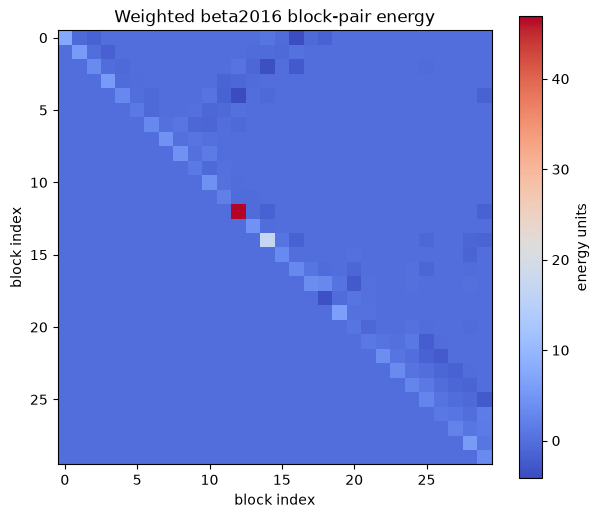

per-term block-pair shape: (24, 1, 30, 30)
summed block-pair shape: (1, 30, 30)
matrix sum: 104.15649 whole-pose score: 104.15656280517578


In [5]:
block_scorer = score_function.render_block_pair_scoring_module(pose_stack)
block_pair_by_term = block_scorer(
    pose_stack.coords, sum_terms=False, apply_weights=True
)
block_pair_total = block_scorer(
    pose_stack.coords, sum_terms=True, apply_weights=True
)

matrix = block_pair_total[0].detach().cpu().numpy()
residue_labels = np.asarray(pose_stack.pdb_info.residue_labels[0])
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(matrix, cmap="coolwarm", aspect="equal")
ax.set(
    title="Weighted beta2016 block-pair energy",
    xlabel="block index",
    ylabel="block index",
)
fig.colorbar(image, ax=ax, label="energy units")
plt.show()

print("per-term block-pair shape:", tuple(block_pair_by_term.shape))
print("summed block-pair shape:", tuple(block_pair_total.shape))
print("matrix sum:", matrix.sum(), "whole-pose score:", total[0].item())

**Expected observations.** Summing every matrix entry reproduces the weighted whole-pose score within numerical tolerance. Diagonal entries include one-body/self contributions; off-diagonal entries describe interactions assigned to block pairs. The matrix is not a cached per-residue energy table.

## Differentiate the score

Because the scoring module consumes a coordinate tensor, ordinary PyTorch autograd provides derivatives. Clone and detach first so the tutorial never mutates the pose's coordinate storage.

In [6]:
differentiable_coords = pose_stack.coords.detach().clone().requires_grad_(True)
differentiable_total = whole_scorer(differentiable_coords).sum()
differentiable_total.backward()
atom_gradient_norm = differentiable_coords.grad[0].norm(dim=-1)
real_gradient_norm = atom_gradient_norm[pose_stack.real_atoms[0]]

records = atom_records_from_pose_stack(pose_stack)
gradient_frame = pd.DataFrame(
    {
        "chain": records["chain"],
        "residue": records["resi"],
        "res_name": records["resn"],
        "atom": records["atomn"],
        "gradient_norm": real_gradient_norm.detach().cpu().numpy(),
    }
).sort_values("gradient_norm", ascending=False)
show_table(gradient_frame.head(20))
print("finite gradients:", torch.isfinite(real_gradient_norm).all().item())

finite gradients: True


## Perturb one nonlocal contact safely

The next cell finds the closest heavy-atom pair between blocks separated by at least three sequence positions. It clones coordinates and moves one atom by only 0.10 Å along the interatomic direction. This is a finite-difference-style diagnostic, not a chemically valid conformational move; bonded and nonbonded terms may both respond.

In [7]:
pbt = pose_stack.packed_block_types
heavy_indices_by_block = []
for block_index in range(pose_stack.max_n_blocks):
    block_type_index = int(pose_stack.block_type_ind64[0, block_index].item())
    block_type = pbt.active_block_types[block_type_index]
    offset = int(pose_stack.block_coord_offset64[0, block_index].item())
    local_heavy = torch.nonzero(
        pbt.atom_is_hydrogen[block_type_index, : len(block_type.atoms)] == 0,
        as_tuple=False,
    ).flatten()
    heavy_indices_by_block.append(local_heavy + offset)

best_distance = float("inf")
best_contact = None
for block_i in range(pose_stack.max_n_blocks):
    for block_j in range(block_i + 3, pose_stack.max_n_blocks):
        atoms_i = heavy_indices_by_block[block_i]
        atoms_j = heavy_indices_by_block[block_j]
        distances = torch.cdist(
            pose_stack.coords[0, atoms_i], pose_stack.coords[0, atoms_j]
        )
        flat_index = int(torch.argmin(distances).item())
        local_i = flat_index // distances.shape[1]
        local_j = flat_index % distances.shape[1]
        distance = float(distances[local_i, local_j].item())
        if distance < best_distance:
            best_distance = distance
            best_contact = (
                block_i,
                block_j,
                int(atoms_i[local_i].item()),
                int(atoms_j[local_j].item()),
            )

block_i, block_j, atom_i, atom_j = best_contact
perturbed_coords = pose_stack.coords.detach().clone()
direction = perturbed_coords[0, atom_j] - perturbed_coords[0, atom_i]
perturbed_coords[0, atom_j] += 0.10 * direction / torch.linalg.vector_norm(direction)

before_terms = whole_scorer(
    pose_stack.coords, sum_terms=False, apply_weights=True
)[:, 0]
after_terms = whole_scorer(
    perturbed_coords, sum_terms=False, apply_weights=True
)[:, 0]
perturbation_frame = pd.DataFrame(
    {
        "term": [score_type.name for score_type in score_types],
        "weighted_before": before_terms.detach().cpu().numpy(),
        "weighted_after": after_terms.detach().cpu().numpy(),
        "delta": (after_terms - before_terms).detach().cpu().numpy(),
    }
).sort_values("delta", key=np.abs, ascending=False)
show_table(perturbation_frame.head(15))
print(
    f"contact blocks {block_i} and {block_j}; initial heavy-atom distance "
    f"{best_distance:.3f} Å"
)

perturbed_pose = pose_stack.clone()
perturbed_pose.coords.copy_(perturbed_coords)
try:
    display(
        tmol.switchable_view(
            {"original": pose_stack, "0.10 Å perturbation": perturbed_pose},
            notes={
                "original": f"closest selected contact: {best_distance:.3f} Å",
                "0.10 Å perturbation": "One contact atom moved along the interatomic direction",
            },
        )
    )
except ImportError as exc:
    print("Interactive coordinate comparison unavailable:", exc)

contact blocks 0 and 16; initial heavy-atom distance 2.564 Å


**Expected observations.** A 0.10 Å change should produce finite, nonzero score deltas. The largest responding terms depend on the chosen contact and local geometry. This experiment demonstrates sensitivity and differentiability; it does not estimate a free energy.

## Plot dominant weighted terms

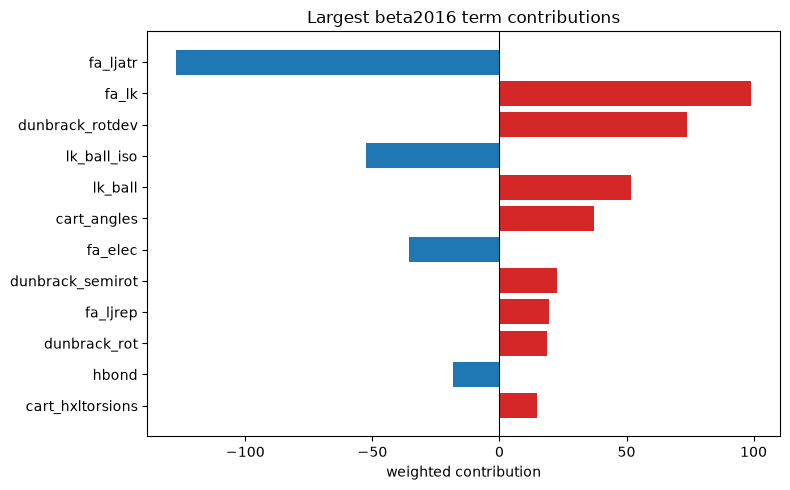

In [8]:
dominant = term_frame.reindex(term_frame["weighted"].abs().sort_values().index).tail(12)
fig, ax = plt.subplots(figsize=(8, 5))
colors = np.where(dominant["weighted"] >= 0, "tab:red", "tab:blue")
ax.barh(dominant["term"], dominant["weighted"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="weighted contribution", title="Largest beta2016 term contributions")
plt.tight_layout()
plt.show()

## Rosetta comparison

Rosetta can switch a pose between centroid and full-atom representations and stores evaluated energies in a pose-associated `Energies` object. TMol's current implementation is **all-atom only**. It renders a scorer for a `PoseStack` layout and returns tensors directly; it does not maintain Rosetta's per-residue `Energies` cache.

Consequently, recompute a whole-pose or block-pair tensor when coordinates change, keep the score-function weights/options with the analysis, and do not call a block-pair matrix a cached per-residue decomposition.

See the full official [Rosetta scoring tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/scoring/scoring), [analysis tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/analysis/Analysis), [full-atom versus centroid tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/full_atom_vs_centroid/fullatom_centroid), [PyRosetta score-function basics](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/03.01-Score-Function-Basics.ipynb), and [analyzing energy between residues](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/03.02-Analyzing-energy-between-residues.ipynb).

## Limitations

- `beta2016` values are model scores, not measured thermodynamic free energies.
- TMol currently supports all-atom scoring only; there is no centroid mode switch.
- Block-pair entries are an accounting decomposition, not independent physical pair potentials.
- TMol has no Rosetta-style pose-resident, per-residue `Energies` cache.
- Coordinate gradients describe the local score landscape and require an appropriate optimizer or constrained protocol before they become useful structural changes.
- A single perturbation and one structure do not quantify uncertainty or ensemble effects.

## Exercises

1. Confirm numerically that `block_pair_by_term.sum((2, 3))` matches `weighted_terms`.
2. Build an unweighted block-pair tensor and inspect how one term changes after the perturbation.
3. Label the matrix axes with author residue numbers for a selected submatrix.
4. Plot per-block sums, taking care to state how diagonal and two orientations are handled.
5. Repeat the gradient analysis after cloning and perturbing a different contact; compare cosine similarity between gradients.

## References

- Park et al., [Simultaneous Optimization of Biomolecular Energy Functions on Features from Small Molecules and Macromolecules](https://pubs.acs.org/doi/10.1021/acs.jctc.6b00819)
- Alford et al., [The Rosetta All-Atom Energy Function for Macromolecular Modeling and Design](https://pubs.acs.org/doi/10.1021/acs.jctc.7b00125)
- [Rosetta scoring tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/scoring/scoring)
- [Rosetta Energy Function workshop slides](https://meilerlab.org/wp-content/uploads/2023/12/Rosetta_Energy_Function.pdf)
- [Rosetta full-atom versus centroid](https://docs.rosettacommons.org/demos/latest/tutorials/full_atom_vs_centroid/fullatom_centroid)
- [PyRosetta score-function basics](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/03.01-Score-Function-Basics.ipynb)